# Dataset

In [2]:
words = open('names.txt', 'r').read().splitlines()

In [3]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(words)

32033

In [5]:
min(len(w) for w in words)

2

In [6]:
max(len(w) for w in words)

15

# Bigram

In [7]:
# build pairs
for w in words[:3]:
    for c1, c2 in zip(w, w[1:]):
        print(c1, c2)

e m
m m
m a
o l
l i
i v
v i
i a
a v
v a


In [8]:
# pairs with start, end tokens
for w in words[:3]:
    chars = ['<S>'] + list(w) + ['<E>']
    for c1, c2 in zip(chars, chars[1:]):
        print(c1, c2)

<S> e
e m
m m
m a
a <E>
<S> o
o l
l i
i v
v i
i a
a <E>
<S> a
a v
v a
a <E>


In [9]:
# create a count of bigrams, bigram == pair of characters
bc = {}
for w in words:
    chars = ['<S>'] + list(w) + ['<E>']
    for c1, c2 in zip(chars, chars[1:]):
        bigram = (c1, c2)
        bc[bigram] = bc.get(bigram, 0)+1

In [10]:
len(bc)

627

In [11]:
# sort by count
sorted(bc.items(), key=lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [12]:
# convert to pytorch arrays

In [13]:
import torch

In [14]:
a = torch.zeros(3, 5, dtype=torch.int32)

In [15]:
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [16]:
N = torch.zeros(28, 28, dtype=torch.int32) # count of bigrams, 28=a-z+<S>+<E>

In [17]:
# lookup table mapper
chars = sorted(list(set(''.join(words))))
chars

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [18]:
ss = set((char, i) for i, char in enumerate(chars))

In [19]:
ss

{('a', 0),
 ('b', 1),
 ('c', 2),
 ('d', 3),
 ('e', 4),
 ('f', 5),
 ('g', 6),
 ('h', 7),
 ('i', 8),
 ('j', 9),
 ('k', 10),
 ('l', 11),
 ('m', 12),
 ('n', 13),
 ('o', 14),
 ('p', 15),
 ('q', 16),
 ('r', 17),
 ('s', 18),
 ('t', 19),
 ('u', 20),
 ('v', 21),
 ('w', 22),
 ('x', 23),
 ('y', 24),
 ('z', 25)}

In [20]:
ss.add(('<S>', 26))

In [21]:
ss.add(('<E>', 27))

In [22]:
stoi = dict(ss)

In [23]:
stoi 

{'i': 8,
 'n': 13,
 'c': 2,
 'p': 15,
 '<E>': 27,
 'q': 16,
 '<S>': 26,
 'b': 1,
 'y': 24,
 'l': 11,
 'x': 23,
 'r': 17,
 't': 19,
 'o': 14,
 'g': 6,
 'w': 22,
 'h': 7,
 'j': 9,
 'u': 20,
 'e': 4,
 'm': 12,
 'v': 21,
 'k': 10,
 'z': 25,
 'f': 5,
 'a': 0,
 'd': 3,
 's': 18}

In [24]:
# build bigram counts with pytorch array over dict
def build_bigram_counts(words=words, stoi=stoi):
    N = torch.zeros(len(words), len(words), dtype=torch.int32)
    for w in words:
        chars = ['<S>'] + list(w) + ['<E>']
        for c1, c2 in zip(chars, chars[1:]):
            i1, i2 = stoi[c1], stoi[c2]
            N[i1][i2] += 1
    return N

In [25]:
N = build_bigram_counts()

In [26]:
N

tensor([[556, 541, 470,  ...,   0,   0,   0],
        [321,  38,   1,  ...,   0,   0,   0],
        [815,   0,  42,  ...,   0,   0,   0],
        ...,
        [  0,   0,   0,  ...,   0,   0,   0],
        [  0,   0,   0,  ...,   0,   0,   0],
        [  0,   0,   0,  ...,   0,   0,   0]], dtype=torch.int32)

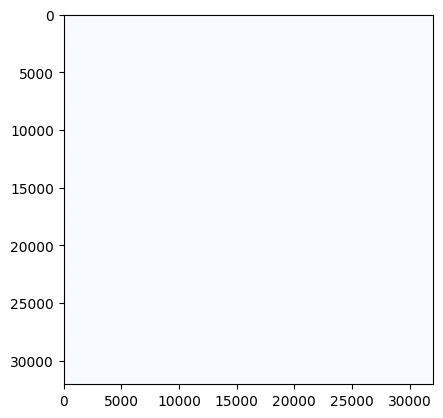

In [27]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.imshow(N.detach().cpu().numpy(), cmap='Blues') # DETACH AND CPU. MEMORIZE THIS.
plt.show()

In [28]:
plt.show()